In [1]:
from RBF_code import *

plt.style.use("bmh")

It is possible to interpolate with other functions than the polynomials. A common one is with RBF functions such as:
$$\phi(x) = \exp(-(\epsilon r)^2), \quad r = |x-x_i|$$
The $\epsilon$ value is known as a shape parameter. It determines how fast a $\phi$ centered at $x_i$ decays. To get a better intuition we have plotted the RBF interpolation of the `Runge` function for different values of $\epsilon$.

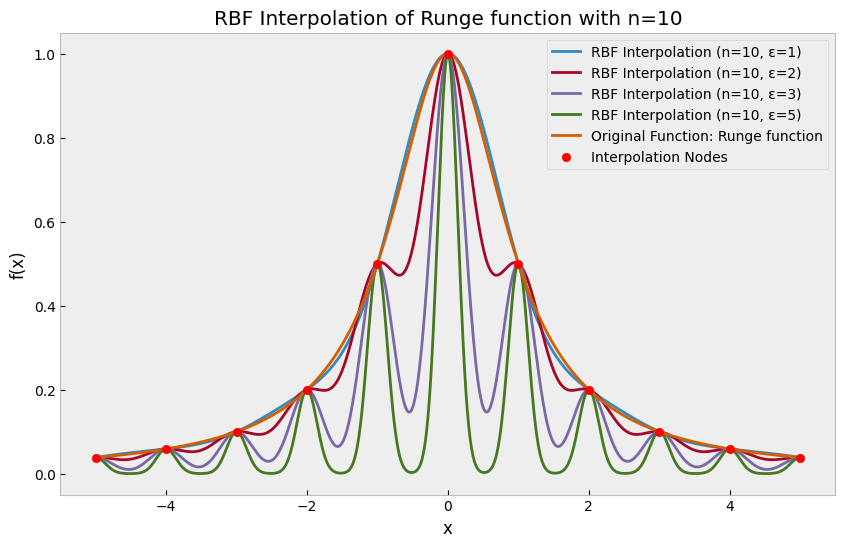

In [2]:
plot_RBF_interpolator(runge_torch,-5,5,10,1,2,3,5)

We clearly see the consequence of having a too large $\epsilon$ value in this plot. The effect of the interpolation in a node dies off before the effect of the next node. But for small enough values the interpolation seems to be really good. What if we have smaller values of  $\epsilon$?

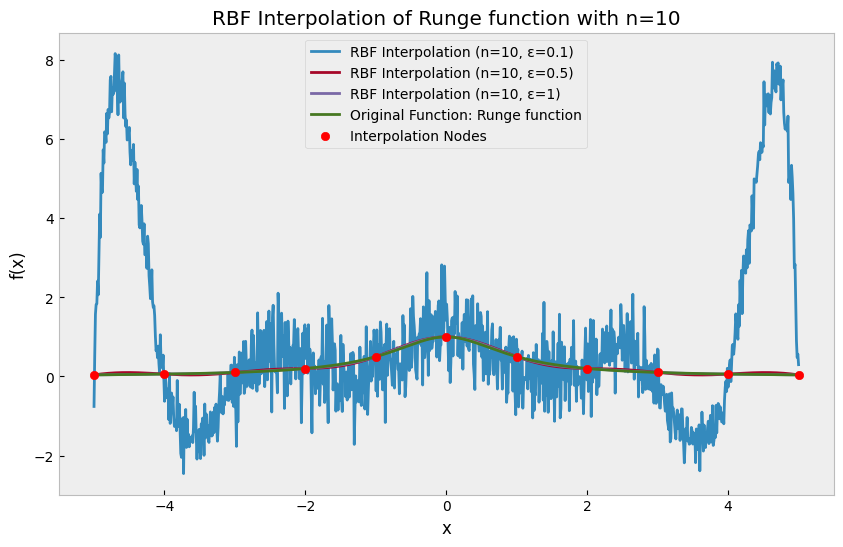

In [3]:
plot_RBF_interpolator(runge_torch,-5,5,10,0.1,0.5,1)

For $\epsilon = 0.5$ we see that the interpolation starts overshooting in a weird way, and for $\epsilon = 0.1$ the interpolation looks to be dominated by random noise. We will look further into the last observation later with condition numbers. But for now $\epsilon = 1$ looks ideal.

So far the `Runge` function is the only one we have considered. What if we start condisering the other functions we have previously looked at?

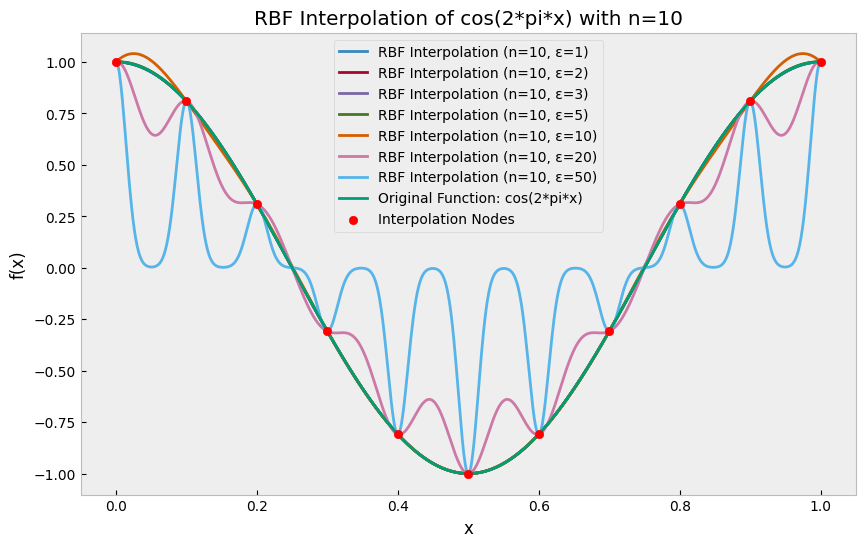

In [4]:
plot_RBF_interpolator(f_cos_torch,0,1,10,1,2,3,5,10,20,50)

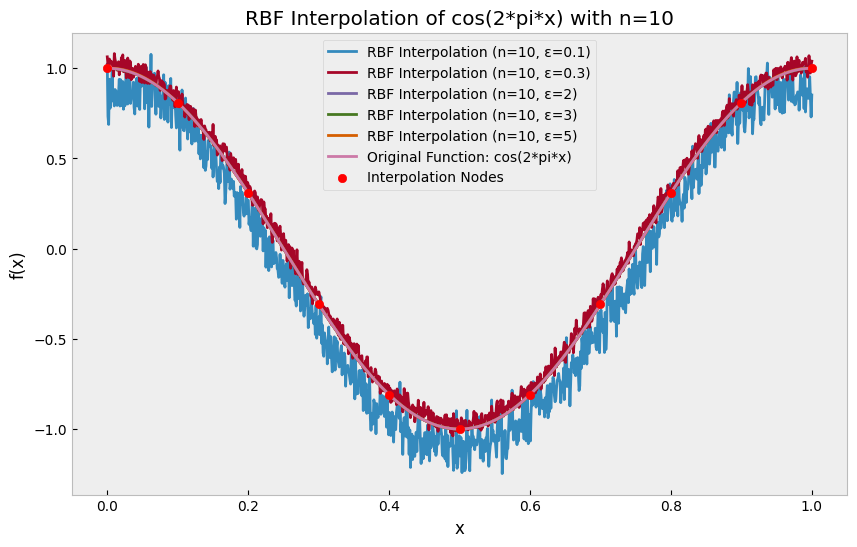

In [21]:
plot_RBF_interpolator(f_cos_torch,0,1,10,0.1,0.3,2,3,5)

$\cos(2\pi)$ reacts differently to the values of $\epsilon$. The noise domination start already at $\epsilon = 1$, which was the previously ideal value. But this function also seems to get good results for way larger values of $\epsilon$, only starting to struggle with $\epsilon = 20$. This can be explained by the tighter grid of nodes. We go from an area of size $10$ to $1$, meaning that the nodes are 10 times as close. Suggesting that $\epsilon$ should be considered with respect to $n$. Here a $\epsilon = 5$ (equivalant to $\epsilon = 0.5$ for the `Runge` function) is ideal. This can be interpreted to mean that an ideal $\epsilon$ value will differ inbetween functions.

The nodes we interpolate over hit excactly the peaks of our function. Could this be the source of the accuracy? To test this we shift our region so that the nodes do not hit the extreme points.

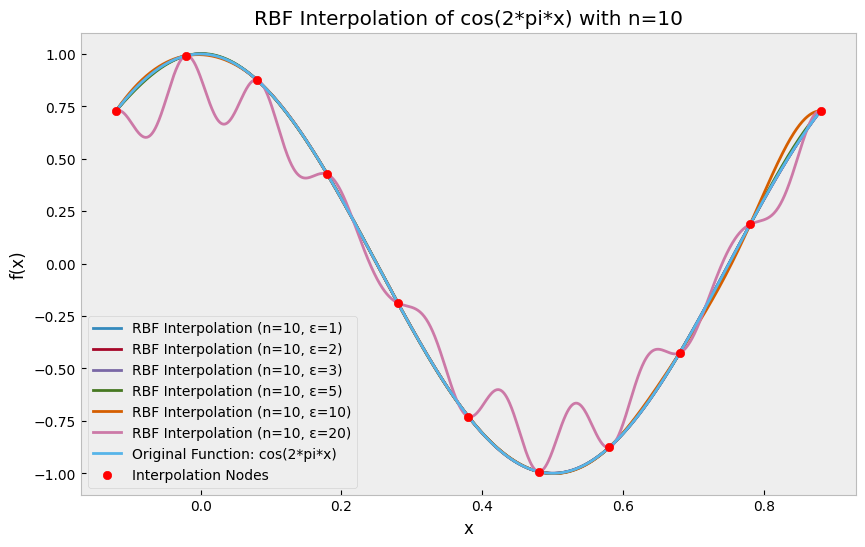

In [5]:
plot_RBF_interpolator(f_cos_torch,-0.12,0.88,10,1,2,3,5,10,20)

We do not see a huge difference, suggesting that the position of the nodes do not have to be ideal for an interpolation to be satisfactory. Of course the position has an effect. If we have 20 nodes on one side and 1 on the other you will get a bad interpolation. But is not a strict requirment. *KANSKJE PLOT DETTE* ?

To look further into this interpolation we consider $e^{3x}\sin(2x)$

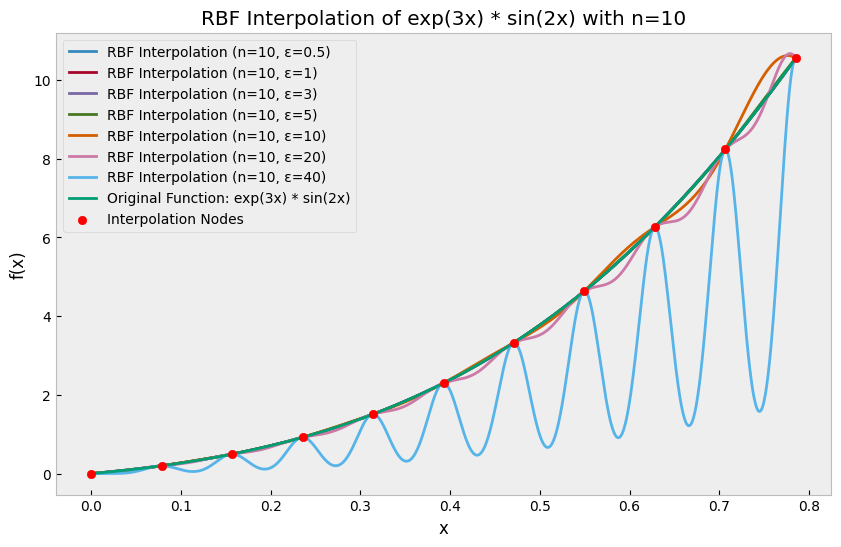

In [6]:
plot_RBF_interpolator(f_expsin_torch,0,torch.pi/4,10,0.5,1,3,5,10,20,40)

*vet ikke helt hva jeg skal skrive her*

Our interpolation function of $f$ is expressed in this form:
$$\tilde f(x) = \sum_{i=0}^{n} w_i\, \varphi(|x - x_i|), \qquad \varphi(r) = e^{-(\varepsilon r)^2}$$
 
Where we require:
$$\tilde f(x_i) = f(x_i), \qquad i = 0,\dots,n$$
 
$$\sum_{j=0}^{n} w_j\, \varphi(|x_i - x_j|) = f(x_i), \qquad i = 0,\dots,n$$
 

To find the weights $w_j$ we introduce a distance matrix
$$M_{i,j} := \varphi(|x_i - x_j|)$$
Our interpolation requirments can then be written using matrix notation:
$$Mw = \mathbf f$$
 
$$w = [w_0,\dots,w_n]^T, \qquad \mathbf f = [f(x_0),\dots,f(x_n)]^T$$
 
$$
\begin{bmatrix}
\varphi(|x_0-x_0|) & \cdots & \varphi(|x_0-x_n|) \\
\vdots & \ddots & \vdots \\
\varphi(|x_n-x_0|) & \cdots & \varphi(|x_n-x_n|)
\end{bmatrix}
\begin{bmatrix} w_0 \\ \vdots \\ w_n \end{bmatrix}
=
\begin{bmatrix} f(x_0) \\ \vdots \\ f(x_n) \end{bmatrix}
$$

So we only need to find values of $w_j$ so that this is satisfied. If $M$ is non-singular this can be found using:
$$w = M^{-1}\mathbf f$$
It is this method we utilise in our interpolation.

This then allows us to use numerical theory to explain the noisy interpolations we observed earlier for low values of $\epsilon$. $M$ is a matrix, meaning it has a condition number $\kappa(M) = ||M||\cdot ||M^{-1}||$

This allows us to use the following theorem from the book:

**Theorem 2.11.** Suppose that $A \in \mathbb{R}^{n \times n}$ is a nonsingular matrix, $b \in \mathbb{R}^n_*$,

$$Ax = b, \qquad A(x + \delta x) = b + \delta b,$$

with $\delta x, \delta b \in \mathbb{R}^n$. Then $x \in \mathbb{R}^n_*$ and

$$\frac{\|\delta x\|}{\|x\|} \le \kappa(A)\, \frac{\|\delta b\|}{\|b\|}.$$

Since our $f$ values can only be represented down to machine precision, along with errors arising in the calculation we can write $\hat{ \mathbf f} = \mathbf f + \delta \mathbf f$. Doing the same for our weights $\hat w = w +dw$ and expressing the actual system we are solving:
$$M(w + \delta w) = \mathbf f + \delta \mathbf f$$
Using the theorem we can derive an upper bound on $\| \delta w/w \|$:
$$\frac{\|\delta w\|}{\|w\|} \le \kappa(M)\, \frac{\|\delta \mathbf{f}\|}{| \mathbf{f}\|}$$

Ideally $\frac{\|\delta \mathbf{f}\|}{\| \mathbf{f}\|} = u \approx 10^{-16} \leftrightarrow \mathbf{\hat f} \text{ is precise down to machine precision.}$ This approximation can differ due to errors arrising when evaluating the function, but our functions are quite nice so we assume that this approximation holds.

Using the theory we have derived so far we can plot the condition number of our $M$ matrix along with the error of the interpolation as a function of $\epsilon$. We suspect that $\kappa(M)$ is large for small $\epsilon$, due to $phi(r) \rightarrow 1$ as $\epsilon \rightarrow 0$ resulting in similar columns of $M \Leftrightarrow$ large $\kappa(M)$. 
 

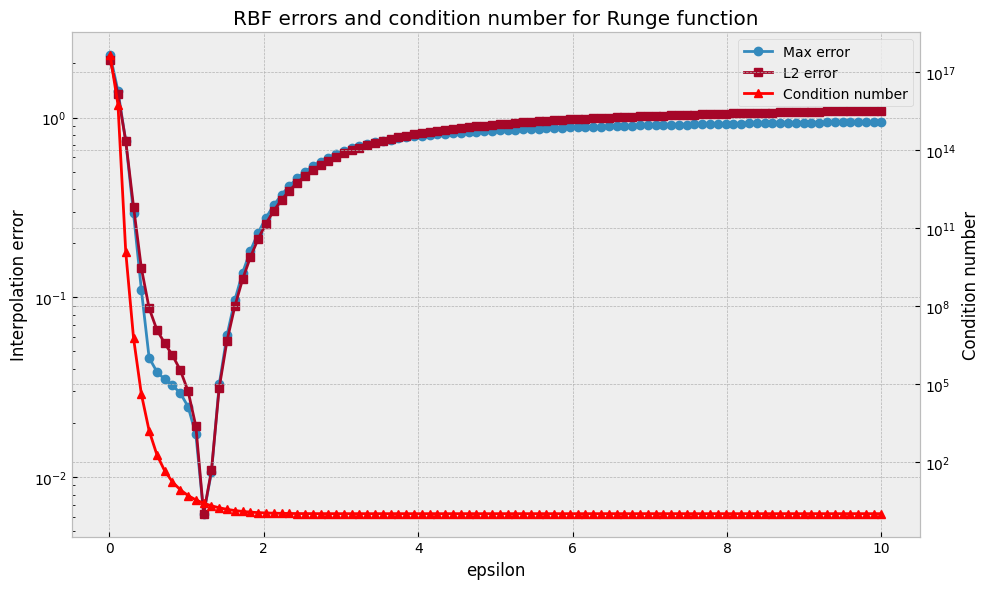

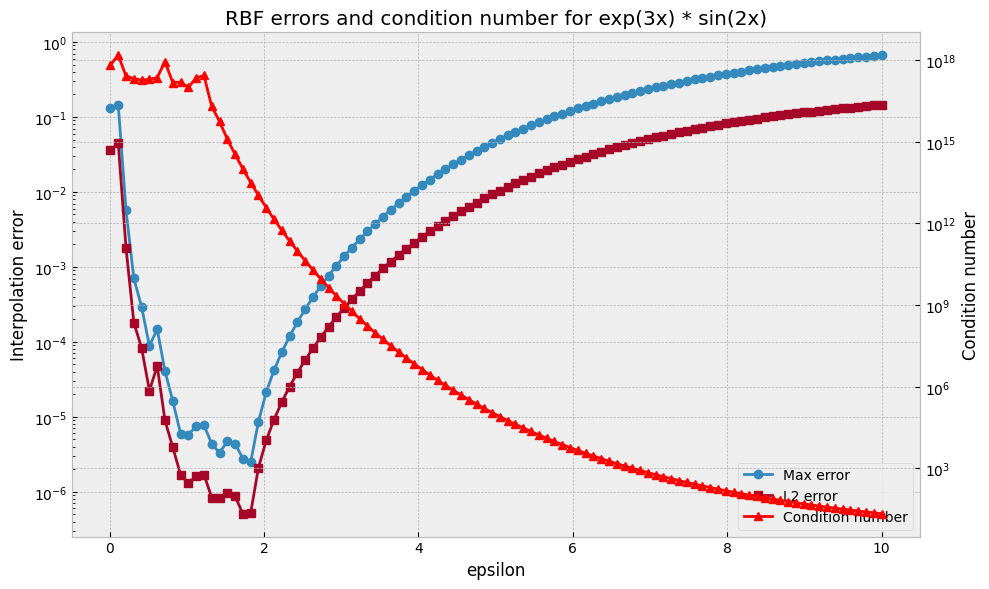

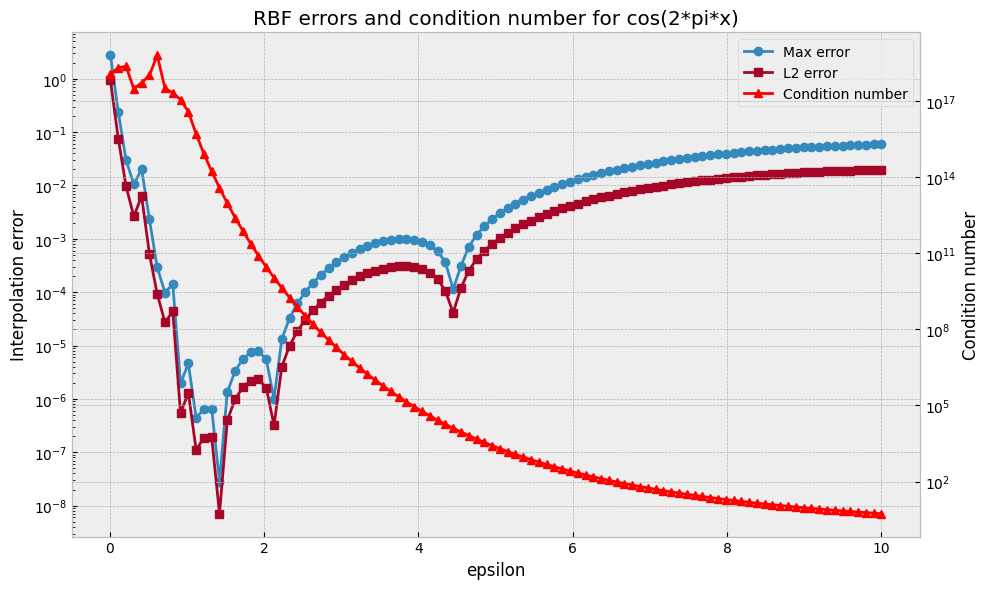

In [19]:
plot_RBF_convergence_condition(runge_torch, -5, 5, 0.01, 10.0, 100, n=10)
plot_RBF_convergence_condition(f_expsin_torch, 0, torch.pi/4, 0.01, 10.0, 100, n=10)
plot_RBF_convergence_condition(f_cos_torch,0,1, 0.01, 10.0, 100, n=10)

These plots give us quite a bit of insight, but also raises some important questions. For the last two functions we observe that for large values of $\kappa(M)$ the error of the interpolation fluctuates by several orders of magnitude. With the error only stabilizing as $\kappa(M)$ decreases. This can be interpreted as that for small values the epsilon the error is dominated by the unstable values of $w$, but as the matrix gets better conditioned with larger values of $\epsilon$ our upper bound of $\delta w$ starts having an effect and the error is instead dominated by the rapid decay of our $\phi$ function. Again we have a tradeoff between stability and precision. If we get high precision for ill-conditioned $M$, why should we care? Well as we see in the plot for the `Runge` function, we do not get good results before the condition number is low enough. We can draw parallels between the choice of epsilon values and the choice between regular interpolation and piecewise interpolation.

We wish to find an acceptable range of values of $\epsilon$. As we know; it will vary based on the chosen function and $[a,b]$. We will primarily focus on $\cos(2\pi x)$ over $[0,1]$. Of course what is accetable will vary based on why we are interpolating so this range will not work for all cases.

First we look at our interpolation error. We rarely get lower than $10^{-6}$. Due to $|\cos(2\pi x)| \leq 1$ we can assume that $w_j \lessapprox 1$ due to $f(x_j) \approx \hat{w}_j \phi(x_j - x_j) = \hat{w}_j$. Making the error bound on $\delta w$ helpfull in creating a bound on the error of our interpolation around our nodes $\Rightarrow e \lessapprox u \cdot \kappa(M) =\kappa(M) 10^{-16}$. This error can be interpreted as the noise error that we saw on plots of the interpolation for small values of $\epsilon$, a reasonable bound on this is $10^{-5}$, more than this and the our interpolant can become unreliable. So we wish for $\kappa(M) \leq 10^{-11}$, giving us the lower bound of our range with $\epsilon \geq 2$ from a stability requirment.

Now the harder part is finding an upper bound. This will vary based on the amount of interpolation points, choice of function, and purpose of interpolation, but we can reasonable require the interpolation to have less than $0.1\%$ error. This is equivalent to the error being less than $10^{-3}$, giving us an upper bound on our range with $\epsilon \leq 5$.

*SNAKKE OM BYTTING AV FORTEGN? ER DET SOM GIR DE DROPPENE I ERROR*